# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [9]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [10]:
import string
import random

class TwoThreeNode:

    def __init__(self, key):
        self.keys = [key]
        self.children = []
        self.parent = None

    def add_key(self, element):
        self.keys.append(element)
        self.keys.sort()

    def add_child(self, child):
        child.parent = self
        if not self.children:
            self.children.append(child)
            return
        for i, c in enumerate(self.children):
            if child.keys[0] < c.keys[0]:
                self.children.insert(i, child)
                return
        self.children.append(child)

    def remove_child(self, child):
        self.children.remove(child)

    def is_leaf(self):
        return len(self.children) == 0

    def is_2_node(self):
        return len(self.keys) == 1

    def is_3_node(self):
        return len(self.keys) == 2

    def is_overflow(self):
        return len(self.keys) > 2
    
class AVLNode:
    def __init__(self, Key):
        self.Key = Key
        self.Left = None
        self.Right = None
        self.Height = 1

def GetNodeHeight(Node):
    return Node.Height if Node else 0

def GetBalanceFactor(Node):
    if not Node: return 0
    RightSubTreeHeight = GetNodeHeight(Node.Right)
    LeftSubTreeHeight = GetNodeHeight(Node.Left)
    BalanceFactor = LeftSubTreeHeight - RightSubTreeHeight
    return BalanceFactor

def RightRotation(UnbalancedRootNode):
    LeftNode = UnbalancedRootNode.Left
    Temp = LeftNode.Right

    LeftNode.Right = UnbalancedRootNode
    UnbalancedRootNode.Left = Temp

    UnbalancedRootNode.Height = 1 + max(GetNodeHeight(UnbalancedRootNode.Left), GetNodeHeight(UnbalancedRootNode.Right))
    LeftNode.Height = 1 + max(GetNodeHeight(LeftNode.Left), GetNodeHeight(LeftNode.Right))

    return LeftNode

def LeftRotation(UnbalancedRootNode):
    RightNode = UnbalancedRootNode.Right
    Temp = RightNode.Left

    RightNode.Left = UnbalancedRootNode
    UnbalancedRootNode.Right = Temp

    UnbalancedRootNode.Height = 1 + max(GetNodeHeight(UnbalancedRootNode.Left), GetNodeHeight(UnbalancedRootNode.Right))
    RightNode.Height = 1 + max(GetNodeHeight(RightNode.Left), GetNodeHeight(RightNode.Right))

    return RightNode
RED = True
BLACK = False
class LLRBNode:
    def __init__(self, key, colour=RED):
        self.key = key
        self.left = None
        self.right = None
        self.colour = colour

Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [11]:
class TwoThreeTree(AbstractSearchInterface):

    def __init__(self):
        self.root = None

    def _find_leaf(self, element):
        node = self.root
        while not node.is_leaf():
            if element in node.keys:
                return None
            if element < node.keys[0]:
                node = node.children[0]
            elif node.is_2_node() or element < node.keys[1]:
                node = node.children[1]
            else:
                node = node.children[2]
        return node

    def _split(self, node):
        left_key  = node.keys[0]
        mid_key   = node.keys[1]
        right_key = node.keys[2]

        left_node  = TwoThreeNode(left_key)
        right_node = TwoThreeNode(right_key)

        if not node.is_leaf():
            left_node.children  = node.children[:2]
            right_node.children = node.children[2:]
            for child in left_node.children:
                child.parent = left_node
            for child in right_node.children:
                child.parent = right_node

        parent = node.parent

        if parent is None:
            new_root = TwoThreeNode(mid_key)
            new_root.children = [left_node, right_node]
            left_node.parent  = new_root
            right_node.parent = new_root
            self.root = new_root
        else:
            parent.remove_child(node)
            parent.add_key(mid_key)
            parent.add_child(left_node)
            parent.add_child(right_node)
            if parent.is_overflow():
                self._split(parent)

    def insertElement(self, element):
        if self.root is None:
            self.root = TwoThreeNode(element)
            return True

        leaf = self._find_leaf(element)

        if leaf is None or element in leaf.keys:
            return False

        leaf.add_key(element)
        if leaf.is_overflow():
            self._split(leaf)

        return True

    def searchElement(self, element):
        node = self.root
        if node is None:
            return False
        while node is not None:
            if element in node.keys:
                return True
            if node.is_leaf():
                return False
            if element < node.keys[0]:
                node = node.children[0]
            elif node.is_2_node() or element < node.keys[1]:
                node = node.children[1]
            else:
                node = node.children[2]
        return False

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [12]:
class AVLTree():
    def __init__(self):
        self.Root = None

    def insertElement(self, Element):
        if self.searchElement(Element):
            return False # Already exists, so return false (no duplicates)

        self.Root = self._Insert(self.Root, Element)
        return True

    def searchElement(self, Element):
        return self._Search(self.Root, Element)

    def _Insert(self, Node, Key):
        if not Node: return AVLNode(Key) 

        if Key < Node.Key:
            Node.Left = self._Insert(Node.Left, Key)
        else:
            Node.Right = self._Insert(Node.Right, Key)

        Node.Height = 1 + max(GetNodeHeight(Node.Left), GetNodeHeight(Node.Right))
        BalanceFactor = GetBalanceFactor(Node)

        if BalanceFactor > 1 and Key < Node.Left.Key:
            return RightRotation(Node)

        if BalanceFactor < -1 and Key > Node.Right.Key:
            return LeftRotation(Node)

        if BalanceFactor > 1 and Key > Node.Left.Key:
            Node.Left = LeftRotation(Node.Left)
            return RightRotation(Node)

        if BalanceFactor < -1 and Key < Node.Right.Key:
            Node.Right = RightRotation(Node.Right)
            return LeftRotation(Node)

        return Node

    def _Search(self, Node, Key):
        if not Node:
            return False
        if Key == Node.Key:
            return True
        if Key < Node.Key:
            return self._Search(Node.Left, Key)
        return self._Search(Node.Right, Key)

    def TreeVisualisation(self, Node = None, Level = 0):
        if Node is None:
            Node = self.Root

        if Node.Right:
            self.TreeVisualisation(Node.Right, Level + 1)

        print("    " * Level + str(Node.Key))

        if Node.Left:
            self.TreeVisualisation(Node.Left, Level + 1)

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [13]:
class LLRBBST(AbstractSearchInterface):

    def __init__(self):
        self.root = None

    def get(self, node, key):
        if node is None:
            return False
        if key == node.key:
            return True
        elif key < node.key:
            return self.get(node.left, key)
        else:
            return self.get(node.right, key)

    def isRed(self, node):
        if node is None:
            return False
        return node.colour == RED

    def rotLeft(self, node):
        x = node.right
        node.right = x.left
        x.left = node
        x.colour = node.colour
        node.colour = RED
        return x

    def rotRight(self, node):
        x = node.left
        node.left = x.right
        x.right = node
        x.colour = node.colour
        node.colour = RED
        return x

    def flipColour(self, node):
        node.colour = RED
        node.left.colour = BLACK
        node.right.colour = BLACK

    def put(self, node, key):
        if node is None:
            return LLRBNode(key, colour=RED)

        if key < node.key:
            node.left = self.put(node.left, key)
        elif key > node.key:
            node.right = self.put(node.right, key)
        else:
            return node

        if self.isRed(node.right) and not self.isRed(node.left):
            node = self.rotLeft(node)

        if self.isRed(node.left) and self.isRed(node.left.left):
            node = self.rotRight(node)

        if self.isRed(node.left) and self.isRed(node.right):
            self.flipColour(node)

        return node

    def searchElement(self, element):
        return self.get(self.root, element)

    def insertElement(self, element):
        if self.searchElement(element):
            return False

        self.root = self.put(self.root, element)
        self.root.colour = BLACK

        return True

Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [14]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [15]:
class ScapegoatTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found 

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [ ]:
import random
import string
import statistics

class TestDataGenerator:

    def __init__(self, seed=42):
        self.seed = seed
        random.seed(seed)

    def _rand_str(self, length=8, rng=None):
        src = rng or random
        return ''.join(src.choices(string.ascii_lowercase, k=length))

    def random_data(self, n, seed=None):
        rng = random.Random(seed if seed is not None else self.seed)
        seen = set()
        result = []
        while len(result) < n:
            s = self._rand_str(rng=rng)
            if s not in seen:
                seen.add(s)
                result.append(s)
        return result

    def sorted_data(self, n, seed=None):
        return sorted(self.random_data(n, seed=seed))

    def reverse_sorted_data(self, n, seed=None):
        return sorted(self.random_data(n, seed=seed), reverse=True)

    def nearly_sorted_data(self, n, swaps=None, seed=None):
        if swaps is None:
            swaps = max(1, n // 50)
        rng = random.Random(seed if seed is not None else self.seed)
        data = self.sorted_data(n, seed=seed)
        for _ in range(swaps):
            i = rng.randint(0, n - 2)
            data[i], data[i + 1] = data[i + 1], data[i]
        return data

    def search_queries(self, data, n=500, hit_ratio=0.5, seed=None):
        rng = random.Random(seed if seed is not None else self.seed)
        data_set = set(data)
        hits = rng.choices(data, k=int(n * hit_ratio))
        misses = []
        while len(misses) < n - len(hits):
            s = self._rand_str(length=9, rng=rng)
            if s not in data_set:
                misses.append(s)
        queries = hits + misses
        rng.shuffle(queries)
        return queries

SyntaxError: unterminated string literal (detected at line 13); perhaps you escaped the end quote? (2848895332.py, line 13)

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [ ]:
import timeit
import statistics
import matplotlib.pyplot as plt

class ExperimentalFramework:

    def __init__(self):
        self.results = {}

    def time_insert(self, ds_class, data, repeats=7):
        """Average over `repeats` full rebuild timings."""
        times = []
        for _ in range(repeats):
            def run():
                ds = ds_class()
                for x in data:
                    ds.insertElement(x)
            times.append(timeit.timeit(run, number=1))
        return statistics.median(times)

    def time_search(self, ds_class, data, queries, repeats=7):
        """Build tree once, then measure search over `repeats` trials."""
        ds = ds_class()
        for x in data:
            ds.insertElement(x)
        times = timeit.repeat(lambda: [ds.searchElement(q) for q in queries],
                              number=1, repeat=repeats)
        return statistics.median(times)

    def run(self, structures, sizes, gen, trials=3):
        """
        For each n, average results across `trials` independently seeded datasets
        so a single unlucky draw doesn\'t skew the results.
        """
        for name, cls in structures.items():
            self.results[name] = {"sizes": [], "insert": [], "search": []}

        for n in sizes:
            # Generate datasets once per n, shared across all structures
            datasets = [(gen.random_data(n, seed=gen.seed + t),
                         gen.search_queries(gen.random_data(n, seed=gen.seed + t),
                                            seed=gen.seed + t))
                        for t in range(trials)]

            for name, cls in structures.items():
                insert_times = []
                search_times = []
                for data, queries in datasets:
                    insert_times.append(self.time_insert(cls, data))
                    search_times.append(self.time_search(cls, data, queries))
                self.results[name]["sizes"].append(n)
                self.results[name]["insert"].append(statistics.mean(insert_times))
                self.results[name]["search"].append(statistics.mean(search_times))
                print(f"  {name} | n={n} done")

    def run_by_distribution(self, structures, n, gen):
        distributions = {
            "random":        gen.random_data(n),
            "sorted":        gen.sorted_data(n),
            "reverse":       gen.reverse_sorted_data(n),
            "nearly sorted": gen.nearly_sorted_data(n),
        }
        results = {name: {} for name in structures}
        for dist_name, data in distributions.items():
            queries = gen.search_queries(data, n=2000)
            for name, cls in structures.items():
                results[name][dist_name] = {
                    "insert": self.time_insert(cls, data),
                    "search": self.time_search(cls, data, queries),
                }
        return results

    def plot_scalability(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        for name, r in self.results.items():
            ax1.plot(r["sizes"], r["insert"], marker="o", label=name)
            ax2.plot(r["sizes"], r["search"], marker="o", label=name)
        for ax, title in zip([ax1, ax2], ["Insert time vs n", "Search time vs n"]):
            ax.set_xlabel("n")
            ax.set_ylabel("seconds")
            ax.set_title(title)
            ax.legend()
            ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_distributions(self, dist_results, operation="insert"):
        names  = list(dist_results.keys())
        dists  = list(next(iter(dist_results.values())).keys())
        x      = range(len(dists))
        width  = 0.8 / len(names)
        fig, ax = plt.subplots(figsize=(9, 5))
        for i, name in enumerate(names):
            times   = [dist_results[name][d][operation] for d in dists]
            offsets = [xi + i * width - (len(names) - 1) * width / 2 for xi in x]
            ax.bar(offsets, times, width=width, label=name)
        ax.set_xticks(list(x))
        ax.set_xticklabels(dists)
        ax.set_ylabel("seconds")
        ax.set_title(f"{operation.capitalize()} time by distribution")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

  2-3 Tree | n=500 done
  2-3 Tree | n=1000 done
  2-3 Tree | n=2500 done
  2-3 Tree | n=5000 done
  2-3 Tree | n=10000 done
  AVL Tree | n=500 done
  AVL Tree | n=1000 done
  AVL Tree | n=2500 done
  AVL Tree | n=5000 done
  AVL Tree | n=10000 done
  LLRB BST | n=500 done
  LLRB BST | n=1000 done
  LLRB BST | n=2500 done
  LLRB BST | n=5000 done
  LLRB BST | n=10000 done


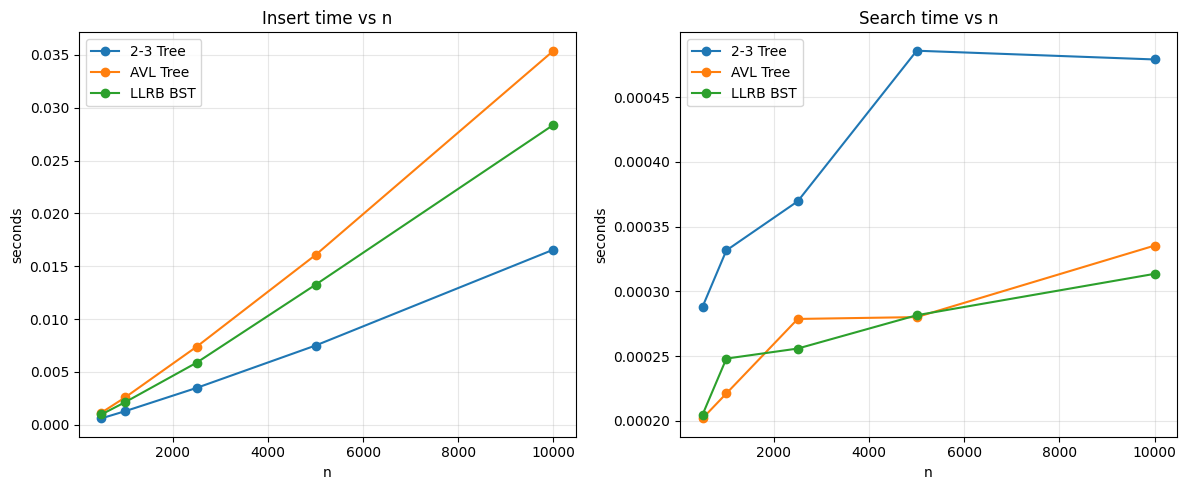

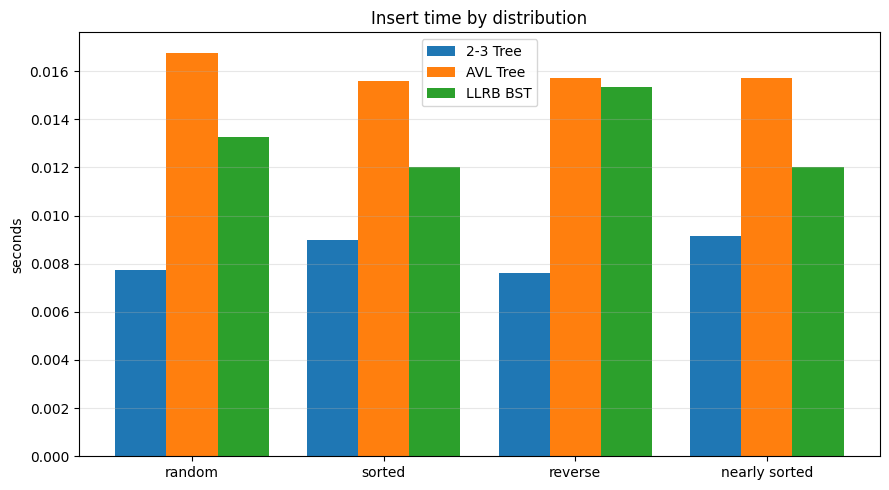

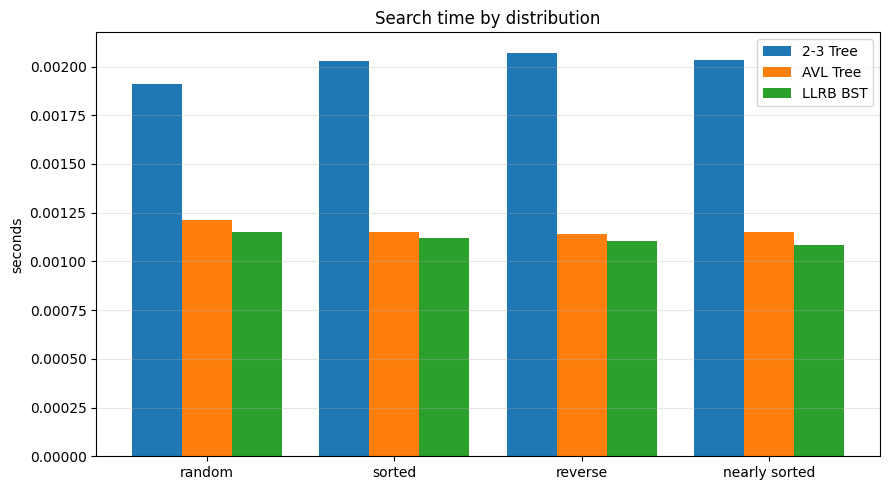

In [ ]:
structures = {
    "2-3 Tree": TwoThreeTree,
    "AVL Tree": AVLTree,
    "LLRB BST": LLRBBST,
}

gen       = TestDataGenerator(seed=42)
framework = ExperimentalFramework()

# Scalability: how does each structure perform as n grows?
framework.run(structures, sizes=[500, 1000, 2500, 5000, 10000], gen=gen)
framework.plot_scalability()

# Distribution: how does insertion order affect performance?
dist_results = framework.run_by_distribution(structures, n=5000, gen=gen)
framework.plot_distributions(dist_results, operation="insert")
framework.plot_distributions(dist_results, operation="search")